In [125]:
# Importing the libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
import matplotlib.colors as mcolors
plt.style.use('classic')
%matplotlib inline
import argparse
import os
import sys
import locale
from matplotlib.colors import ListedColormap, BoundaryNorm 

from IPython.display import HTML
locale.setlocale(locale.LC_TIME, "es_ES")

sns.set()

In [126]:
class WaterBalanceModel:
    def __init__(self, codcuenca_n3, model_variable):
        self.codcuenca_n3 = codcuenca_n3
        self.model_variable = model_variable

    def set_criteria_values(self, values, flow_cat):    
        self.values = values
        self.flow_cat = flow_cat

    def importmodelvariable(self):
        df_runoff = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/{self.model_variable}.csv', usecols=lambda col: col == str(self.codcuenca_n3) or col.startswith('-1'))
        df_runoff = df_runoff.rename(columns={'-1': 'year', '-1.1':'month'})
        df_runoff['date'] = pd.to_datetime(dict(year=df_runoff['year'], month=df_runoff['month'], day=1))
        df_runoff = df_runoff.set_index('date')
        df_runoff['days_in_month'] = df_runoff.index.days_in_month
        # change column name for runoff column to runoff
        df_runoff = df_runoff.rename(columns=lambda col: 'RF' if col not in ['year', 'month', 'date', 'days_in_month'] else col)
        return df_runoff

    def convertRunoff2Discharge(self, df_runoff):
        basin_level3 = pd.read_csv(f'./waterbalance/balance_hidrico_regional/output_modelo/cuenca_nivel3.csv',usecols=lambda col: col == str(self.codcuenca_n3))
        df_runoff_selected = df_runoff.drop(['year', 'month', 'days_in_month'], axis=1)
        df_discharge = pd.DataFrame(df_runoff_selected.values * 1000 * basin_level3.values, columns=df_runoff_selected.columns)
        df_discharge['days_in_month'] = df_runoff['days_in_month'].values
        df_discharge = df_discharge.loc[:, df_discharge.columns != 'days_in_month'].divide(df_discharge["days_in_month"] * 24 * 3600, axis="index")
        df_discharge['date'] = df_runoff.index.values
        df_discharge = df_discharge.set_index('date')
        df_discharge['year'] = df_runoff['year'].values
        df_discharge['month'] = df_runoff['month'].values
        # change column name for discharge column to Caudal
        df_discharge = df_discharge.rename(columns=lambda col: 'Caudal' if col not in ['year', 'month', 'date'] else col)
        return df_discharge

    def estado_mensual(self, DISCHARGE_MONTHLY, alphap=0.4, betap=0.4):
            # Climatologia
            DISCHARGE_SELECTION = DISCHARGE_MONTHLY[(DISCHARGE_MONTHLY['year'] >= 1981) & (DISCHARGE_MONTHLY['year'] <= 2010)]
            DISCHARGE_AVERAGE = DISCHARGE_SELECTION.groupby(DISCHARGE_SELECTION.month).mean()
            DISCHARGE_AVERAGE = DISCHARGE_AVERAGE.reindex(columns=['Caudal'])
            # Calcular indicadores
            DISCHARGE_MONTHLY['average_percentage'] = np.nan
            DISCHARGE_MONTHLY['rank_average'] = np.nan
            DISCHARGE_MONTHLY['non_missing'] = np.nan
    
            for i in range(len(DISCHARGE_MONTHLY)):
                # Extract the current month 
                m = DISCHARGE_MONTHLY.month[i]
                # Extract the current year
                y = DISCHARGE_MONTHLY.year[i]
                DISCHARGE_MONTHLY.loc[DISCHARGE_MONTHLY.eval('month==@m & year==@y'),'rank_average']  = DISCHARGE_MONTHLY.query('month==@m')['Caudal'].rank()
                DISCHARGE_MONTHLY.loc[DISCHARGE_MONTHLY.eval('month==@m & year==@y'),'non_missing']  = DISCHARGE_MONTHLY.query('month==@m')["Caudal"].notnull().sum()
                DISCHARGE_MONTHLY.loc[DISCHARGE_MONTHLY.eval('month==@m & year==@y'),'average_percentage'] = (DISCHARGE_MONTHLY['Caudal'][i] - DISCHARGE_AVERAGE.query('month == @m')["Caudal"].item()) / DISCHARGE_AVERAGE.query('month == @m')["Caudal"].item()
    
            DISCHARGE_MONTHLY['percentile'] = (DISCHARGE_MONTHLY['rank_average']- alphap) / (DISCHARGE_MONTHLY['non_missing'] + 1 - alphap - betap)
    
            criteria = [DISCHARGE_MONTHLY['percentile'].between(0.90,1.00),
                DISCHARGE_MONTHLY['percentile'].between(0.75,0.90),
                DISCHARGE_MONTHLY['percentile'].between(0.25,0.75),
                DISCHARGE_MONTHLY['percentile'].between(0.10,0.25),
                DISCHARGE_MONTHLY['percentile'].between(0.00,0.10)]

            # Assign percentile ranges and flow categories based on criteria
            self.set_criteria_values(
                values = ['High flow','Above normal','Normal range','Below normal','Low flow'],
                flow_cat = [5,4,3,2,1]
            )

            DISCHARGE_MONTHLY['percentile_range'] = np.select(criteria,self.values,None)
            DISCHARGE_MONTHLY['flowcat'] = np.select(criteria,self.flow_cat,pd.NA)
    
            return DISCHARGE_MONTHLY


In [127]:
codcuenca_n3 = '295'
model_instance = WaterBalanceModel(codcuenca_n3, 'Escorrentia_total')

In [128]:
basins_n3 = pd.read_csv(f'./waterbalance/cuenca_nivel3.csv',encoding='ANSI')

In [129]:
# from basins_n3 extract the rows corresponding to a specific codcuenca_n3
basin_n3 = basins_n3[basins_n3['C3'] == float(codcuenca_n3)]
basin_n3

,C3,NOMBRE
120,295,Ao. Del Potrero y Laguna del Sauce


In [130]:
# Import variable
df_runoff = model_instance.importmodelvariable()
df_runoff

,year,month,RF,days_in_month
date,,,,
1980-01-01,1980,1,5.1534,31
1980-02-01,1980,2,23.2210,29
1980-03-01,1980,3,12.3380,31
1980-04-01,1980,4,39.2710,30
1980-05-01,1980,5,31.1500,31
...,...,...,...,...
2026-04-01,2026,4,32.0590,30
2026-05-01,2026,5,29.6190,31
2026-06-01,2026,6,13.6210,30


In [131]:
# Convert level 3 runoff to discharge
df_discharge = model_instance.convertRunoff2Discharge(df_runoff)
df_discharge

,Caudal,year,month
date,,,
1980-01-01,1.369930,1980,1
1980-02-01,6.598560,1980,2
1980-03-01,3.279815,1980,3
1980-04-01,10.787404,1980,4
1980-05-01,8.280615,1980,5
...,...,...,...
2026-04-01,8.806330,2026,4
2026-05-01,7.873629,2026,5
2026-06-01,3.741571,2026,6


In [132]:
df_status = model_instance.estado_mensual(df_discharge, alphap=0.4, betap=0.4)

In [133]:
df_status.tail(12)

,Caudal,year,month,average_percentage,rank_average,non_missing,percentile,percentile_range,flowcat
date,,,,,,,,,
2025-09-01,4.484886,2025,9,-0.662609,5.0,46.0,0.099567,Low flow,1
2025-10-01,3.020099,2025,10,-0.754542,7.0,46.0,0.142857,Below normal,2
2025-11-01,1.669986,2025,11,-0.763293,7.0,46.0,0.142857,Below normal,2
2025-12-01,0.600511,2025,12,-0.851186,4.0,46.0,0.077922,Low flow,1
2026-01-01,0.223138,2026,1,-0.910577,4.0,47.0,0.076271,Low flow,1
2026-02-01,0.091796,2026,2,-0.981833,3.0,47.0,0.055085,Low flow,1
2026-03-01,2.445878,2026,3,-0.652430,25.0,47.0,0.521186,Normal range,3
2026-04-01,8.806330,2026,4,0.249940,37.0,47.0,0.775424,Above normal,4
2026-05-01,7.873629,2026,5,-0.208779,31.0,47.0,0.648305,Normal range,3


In [134]:
def plot_heatmap_status_single_basin(
    df_status,
    allbasins_df=None,
    back_months=None,
    output_file=None,
    figsize=(18, 3.2),
):
    """Genera un heatmap de estado hidrológico mensual para una subcuenca específica

    a partir de df_status.

    Parameters:
    -----------
    df_status : pd.DataFrame
        DataFrame con las columnas 'date'/'Date' y 'flowcat'.
    allbasins_df : pd.DataFrame, optional
        DataFrame con 1 fila con columnas 'codcuenca' y 'nombre'.
    back_months : int, optional
        Número de meses recientes a mostrar (ej: 12, 24). Si es None, muestra todo.
    output_file : str, optional
        Ruta para guardar la imagen generada.
    figsize : tuple, default (18, 3.2)
        Dimensiones de la figura.
    """
    # 1. Preparar datos
    df_plot = df_status.copy()
    if "date" not in df_plot.columns and "Date" not in df_plot.columns:
        df_plot = df_plot.reset_index()

    date_col = "date" if "date" in df_plot.columns else "Date"
    df_plot[date_col] = pd.to_datetime(df_plot[date_col])
    df_plot["flowcat"] = pd.to_numeric(df_plot["flowcat"], errors="coerce")
    df_plot = df_plot.sort_values(by=date_col)

    # Filtrar últimos N meses si se especifica
    if back_months is not None:
        df_plot = df_plot.tail(back_months)

    # 2. Pivotar a una fila (1 subcuenca x N fechas)
    # Formato de columna: MMM-YYYY (ej. SEP-2025)
    df_plot["label_fecha"] = df_plot[date_col].dt.strftime("%b-%Y").str.upper()

    piv_df = df_plot.set_index(date_col)[["flowcat"]].T
    piv_df.index = ["Estado"]

    # 3. Configurar paleta de colores y normalización discreta
    colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
    cmap = mcolors.ListedColormap(colors)
    bounds = [1, 2, 3, 4, 5, 6]
    norm = mcolors.BoundaryNorm(bounds, ncolors=len(colors))

    font_size = 12

    # 4. Graficar Heatmap
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        piv_df,
        square=False,
        cmap=cmap,
        norm=norm,
        mask=piv_df.isna(),
        annot=False,
        linewidths=1.0,
        linecolor="black",
        ax=ax,
        cbar_kws={"orientation": "vertical", "shrink": 0.85, "pad": 0.02},
    )

    # 5. Título
    if allbasins_df is not None and not allbasins_df.empty:
        basin_row = allbasins_df.iloc[0]
        title_str = f"Estado Hidrológico - {basin_row['nombre']} (Cuenca {basin_row['codcuenca']})"
    else:
        title_str = "Estado Hidrológico Mensual"

    ax.set_title(title_str, pad=18, loc="center", fontsize=font_size + 4)

    # 6. Ejes
    ax.set_xlabel("Fecha", labelpad=10, fontsize=font_size + 1)
    ax.set_xticks(np.arange(len(df_plot)) + 0.5)
    ax.set_xticklabels(df_plot["label_fecha"], rotation=90, fontsize=font_size)

    ax.set_ylabel("")
    ax.yaxis.set_visible(False)

    # 7. Barra de colores personalizada
    colorbar = ax.collections[0].colorbar
    tick_centers = [(b0 + b1) / 2 for b0, b1 in zip(bounds[:-1], bounds[1:])]
    colorbar.set_ticks(tick_centers)
    colorbar.set_ticklabels(
        [
            "Flujo bajo",
            "Por debajo de lo normal",
            "Normal",
            "Por encima de lo normal",
            "Flujo alto",
        ],
        fontsize=font_size - 1,
    )
    colorbar.ax.yaxis.set_tick_params(rotation=0)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")

    return fig, ax

In [135]:
def plot_heatmap_cuenca_eventos(
    station_name,
    df_status=None,
    eventos=None,
    start_month=8,
    end_month=4,
    allbasins_n2=None,
    output_file=None,
    figsize=(20, 6),
):
    """Genera un heatmap del estado hidrológico mensual para eventos seleccionados

    a partir de df_status.

    Parameters:
    -----------
    station_name : str or int
        Código de la cuenca/estación.
    df_status : pd.DataFrame, optional
        DataFrame con columnas ['date'/'Date', 'flowcat'] o ['year', 'month',
        'flowcat'].
        Si es None, intenta instanciar EstadoHidrologico(station_name).
    eventos : list of str, optional
        Lista de períodos (ej: ['1982/1983', '1991/1992', '1997/1998',
        '2015/2016', '2023/2024']).
    start_month : int, default 8
        Mes inicial del evento (1-12).
    end_month : int, default 4
        Mes final del evento (1-12).
    allbasins_n2 : pd.DataFrame, optional
        DataFrame con columnas 'codcuenca' y 'nombre'.
    output_file : str, optional
        Ruta para guardar la figura generada.
    figsize : tuple, default (20, 6)
        Dimensiones de la figura en pulgadas.
    """
    if eventos is None:
        eventos = [
            "1982/1983",
            "1991/1992",
            "1997/1998",
            "2015/2016",
            "2023/2024",
        ]

    # 1. Obtener y estandarizar df_status
    if df_status is None:
        values = [
            "High flow",
            "Above normal",
            "Normal range",
            "Below normal",
            "Low flow",
        ]
        flow_cat = [5, 4, 3, 2, 1]
        hydro = EstadoHidrologico(
            station_name=str(station_name), values=values, flow_cat=flow_cat
        )
        hydro.cargar_datos()
        df_status = hydro.estado_mensual()

    df_base = df_status.copy()
    if "Date" not in df_base.columns and "date" not in df_base.columns:
        if df_base.index.name in ["Date", "date"]:
            df_base = df_base.reset_index()

    # Asegurar columnas 'year' y 'month' a partir de la fecha
    date_col = (
        "date"
        if "date" in df_base.columns
        else ("Date" if "Date" in df_base.columns else None)
    )
    if date_col:
        df_base[date_col] = pd.to_datetime(df_base[date_col])
        df_base["year"] = df_base[date_col].dt.year
        df_base["month"] = df_base[date_col].dt.month

    df_base["flowcat"] = pd.to_numeric(df_base["flowcat"], errors="coerce")

    # 2. Secuencia ordenada de meses
    meses_nombres = {
        1: "ENE",
        2: "FEB",
        3: "MAR",
        4: "ABR",
        5: "MAY",
        6: "JUN",
        7: "JUL",
        8: "AGO",
        9: "SEP",
        10: "OCT",
        11: "NOV",
        12: "DIC",
    }

    is_cross_year = start_month >= end_month
    if is_cross_year:
        meses_ciclo = [(m, 1) for m in range(start_month, 13)] + [
            (m, 2) for m in range(1, end_month + 1)
        ]
    else:
        meses_ciclo = [(m, 1) for m in range(start_month, end_month + 1)]

    # Etiquetas de columnas en el eje X (ej: ['AGO', 'SEP', ..., 'ABR'])
    cols_nombres = [meses_nombres[m] for m, _ in meses_ciclo]

    # 3. Construir matriz del Heatmap (Filas = Eventos, Columnas = Meses)
    matriz = pd.DataFrame(index=eventos, columns=cols_nombres, dtype=float)

    for evento in eventos:
        if "/" in str(evento):
            y1, y2 = [int(y) for y in str(evento).split("/")]
        else:
            y1 = int(evento)
            y2 = y1 + 1 if is_cross_year else y1

        for idx_col, (m, yr_order) in enumerate(meses_ciclo):
            target_year = y1 if yr_order == 1 else y2
            col_name = cols_nombres[idx_col]

            val = df_base.loc[
                (df_base["year"] == target_year) & (df_base["month"] == m),
                "flowcat",
            ]
            if not val.empty and pd.notnull(val.values[0]):
                matriz.iloc[matriz.index.get_loc(evento), idx_col] = float(
                    val.values[0]
                )

    # 4. Paleta y límites HydroSOS
    colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
    cmap = mcolors.ListedColormap(colors)
    bounds = [1, 2, 3, 4, 5, 6]
    norm = mcolors.BoundaryNorm(bounds, ncolors=len(colors))

    # 5. Configurar gráfico
    font_title = 18
    font_labels = 14
    font_ticks = 12
    font_cbar = 11

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        matriz,
        cmap=cmap,
        norm=norm,
        linewidths=1.5,
        linecolor="black",
        square=True,
        cbar_kws={"shrink": 0.8, "pad": 0.03},
        ax=ax,
    )

    # 6. Título y nombres de cuenca
    if allbasins_n2 is not None and not allbasins_n2.empty:
        allbasins_basin = allbasins_n2.loc[
            allbasins_n2["codcuenca"].astype(str) == str(station_name)
        ].reset_index(drop=True)
        if not allbasins_basin.empty:
            basin_row = allbasins_basin.iloc[0]
            title_text = f"Estado Hidrológico - {basin_row['nombre']} (Código cuenca {basin_row['codcuenca']})"
        else:
            title_text = f"Estado Hidrológico - Cuenca {station_name}"
    else:
        title_text = f"Estado Hidrológico - Cuenca {station_name}"

    ax.set_title(title_text, fontsize=font_title, fontweight="bold", pad=20)
    ax.set_xlabel("Mes", fontsize=font_labels, fontweight="bold", labelpad=12)
    ax.set_ylabel("Eventos", fontsize=font_labels, fontweight="bold", labelpad=12)

    ax.tick_params(axis="x", rotation=0, labelsize=font_ticks)
    ax.tick_params(axis="y", rotation=0, labelsize=font_ticks)

    # 7. Barra de color
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([(b0 + b1) / 2 for b0, b1 in zip(bounds[:-1], bounds[1:])])
    cbar.set_ticklabels(
        [
            "Flujo bajo",
            "Por debajo de lo normal",
            "Normal",
            "Por encima de lo normal",
            "Flujo alto",
        ]
    )
    cbar.ax.tick_params(labelsize=font_cbar)

    plt.tight_layout()

    if output_file:
        plt.savefig(
            output_file, dpi=300, bbox_inches="tight", facecolor="white"
        )

    return fig, ax

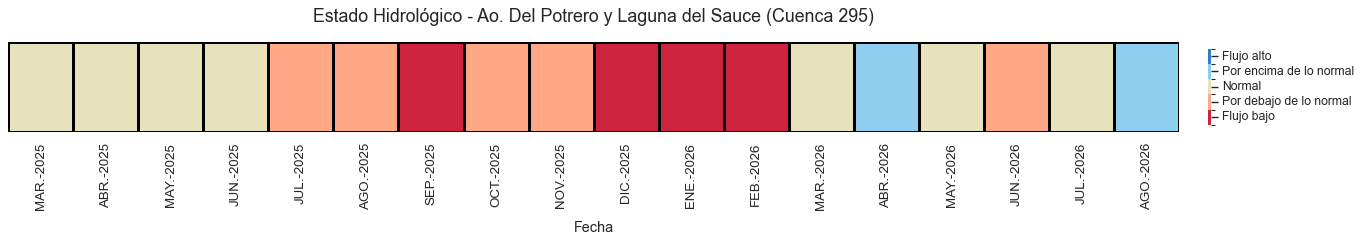

In [147]:
# Ejemplo 1: Con metadatos de la subcuenca
info_cuenca = pd.DataFrame([{"codcuenca": codcuenca_n3, "nombre": basin_n3.iloc[0]['NOMBRE']}])

fig, ax = plot_heatmap_status_single_basin(
    df_status=df_status,
    allbasins_df=info_cuenca,
    back_months=18,  # Opcional: muestra los últimos 18 meses
    output_file="",
)
plt.show()



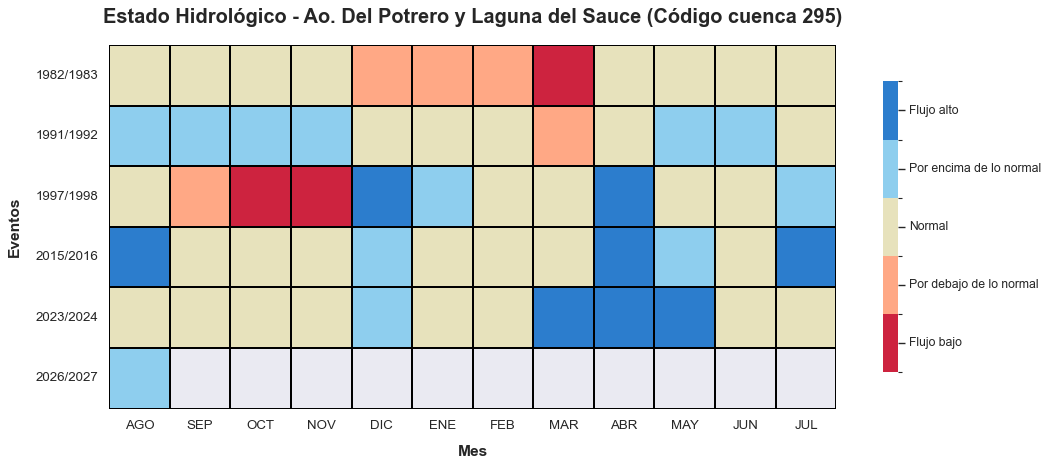

In [157]:
fig2, ax2 = plot_heatmap_cuenca_eventos(
    df_status=df_status,
    station_name=codcuenca_n3,
    eventos=['1982/1983', '1991/1992', '1997/1998', '2015/2016', '2023/2024', '2026/2027'],
    start_month = 8,
    end_month = 7,
    allbasins_n2=info_cuenca,
    output_file="",
    figsize=(20, 6)
)
plt.show()